# EDA — CBC Test Dataset

**Nguồn**: Kaggle `abdelrhmankaram/complete-blood-count-cbc-test`, lấy qua repo GitHub `Pfuglo1/anemia-detection-cbc-ml`.

**File**: `Data/tabular/anemia_cbc_ml_repo/cbc information.xlsx` — 500 dòng × 21 cột chỉ số CBC đầy đủ, **không có nhãn bệnh**.

Mục tiêu EDA: kiểm tra chất lượng dữ liệu (missing, trùng lặp, giá trị vô lý), phân phối từng chỉ số, tương quan giữa các biến.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 5)
DATA = Path(r'D:\AI_08_V1\Data')

df = pd.read_excel(DATA / 'tabular' / 'anemia_cbc_ml_repo' / 'cbc information.xlsx')
print('Shape:', df.shape)
df.head()

Shape: (500, 21)


,ID,WBC,LYMp,MIDp,NEUTp,LYMn,MIDn,NEUTn,RBC,HGB,...,MCV,MCH,MCHC,RDWSD,RDWCV,PLT,MPV,PDW,PCT,PLCR
0,1,10.0,43.2,6.7,50.1,4.3,0.7,5.0,2.77,7.3,...,87.7,26.3,30.1,35.3,11.4,189.0,9.2,12.5,0.17,22.3
1,2,10.0,42.4,5.3,52.3,4.2,0.5,5.3,2.84,7.3,...,88.2,25.7,20.2,35.3,11.4,180.0,8.9,12.5,0.16,19.5
2,3,7.2,30.7,8.6,60.7,2.2,0.6,4.4,3.97,9.0,...,77.0,22.6,29.5,37.2,13.7,148.0,10.1,14.3,0.14,30.5
3,4,6.0,30.2,6.3,63.5,1.8,0.4,3.8,4.22,3.8,...,77.9,23.2,29.8,46.5,17.0,143.0,8.6,11.3,0.12,16.4
4,5,4.2,39.1,7.2,53.7,1.6,0.3,2.3,3.93,0.4,...,80.6,23.9,29.7,42.7,15.1,236.0,19.5,12.8,0.22,24.8


In [2]:
# Missing values & duplicates
print('Missing values:\n', df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else 'Không có missing value')
print('\nDòng trùng lặp:', df.duplicated().sum())
df.describe().T[['mean', 'std', 'min', '50%', 'max']].round(2)

Missing values:
 Không có missing value

Dòng trùng lặp: 0


,mean,std,min,50%,max
ID,250.50,144.48,1.00,250.50,500.0
WBC,7.37,3.70,0.80,6.70,45.7
LYMp,25.84,11.27,6.20,24.80,91.4
MIDp,8.69,6.96,0.50,7.80,77.0
NEUTp,77.51,236.63,0.70,66.95,5317.0
LYMn,1.88,2.14,0.20,1.60,41.8
MIDn,0.67,0.83,0.10,0.50,10.0
NEUTn,5.14,4.60,0.50,4.40,79.0
RBC,4.88,4.40,1.42,4.59,90.8
HGB,11.74,5.63,-10.00,11.50,87.1


Số dòng vi phạm khoảng sinh học hợp lý:
  HGB     :    8 dòng ngoài [3, 20]  (min=-10.0, max=87.1)
  MCV     :    8 dòng ngoài [50, 130]  (min=-79.3, max=990.0)
  NEUTp   :    2 dòng ngoài [0, 100]  (min=0.7, max=5317.0)
  LYMp    :    0 dòng ngoài [0, 100]  (min=6.2, max=91.4)
  HCT     :    5 dòng ngoài [10, 65]  (min=2.0, max=3715.0)
  MPV     :    8 dòng ngoài [5, 20]  (min=0.1, max=919.0)
  PLT     :    0 dòng ngoài [0, 1000]  (min=11.3, max=508.0)
  WBC     :    0 dòng ngoài [0, 100]  (min=0.8, max=45.7)


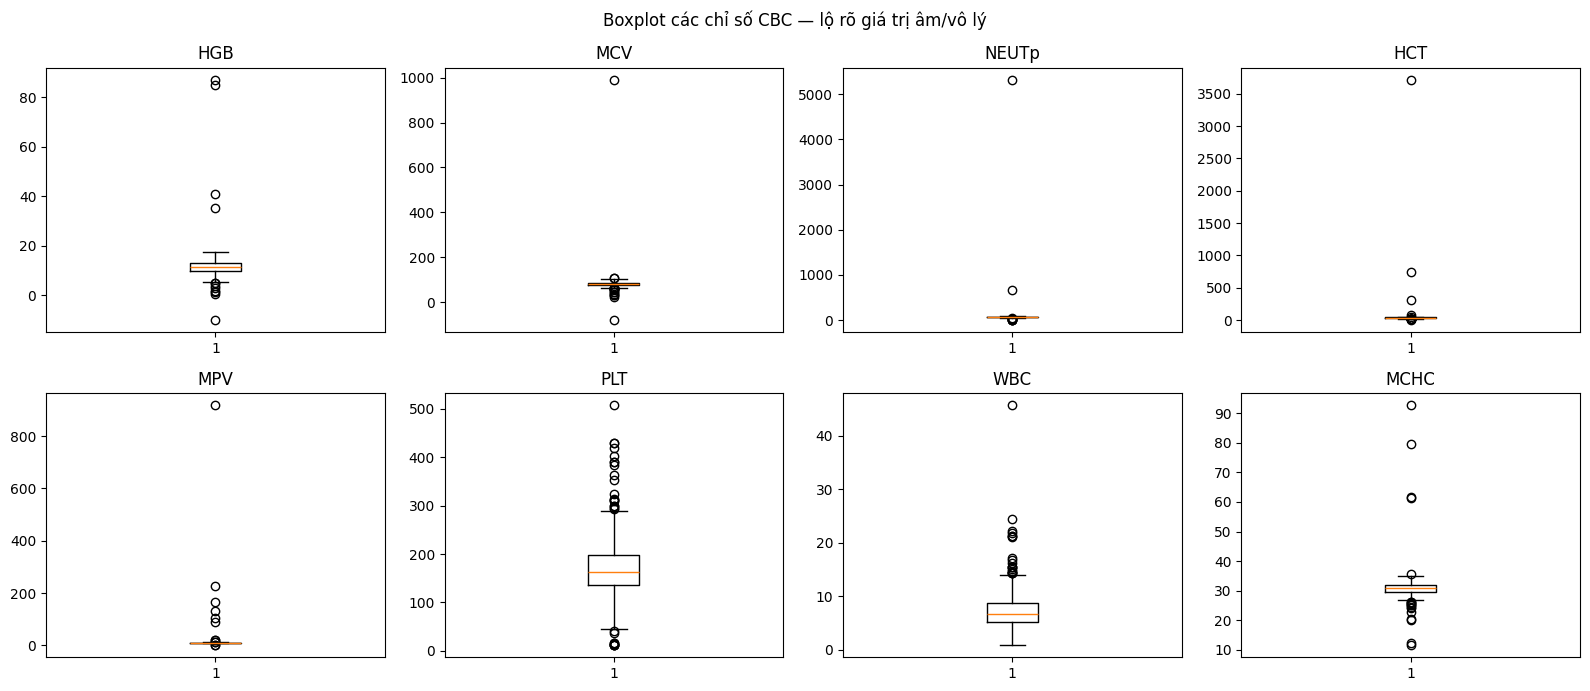

In [3]:
# Kiểm tra giá trị vô lý / ngoài khoảng sinh học hợp lý
biological_range = {
    'HGB': (3, 20), 'MCV': (50, 130), 'NEUTp': (0, 100), 'LYMp': (0, 100),
    'HCT': (10, 65), 'MPV': (5, 20), 'PLT': (0, 1000), 'WBC': (0, 100),
}
print('Số dòng vi phạm khoảng sinh học hợp lý:')
for col, (lo, hi) in biological_range.items():
    n_invalid = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'  {col:8s}: {n_invalid:4d} dòng ngoài [{lo}, {hi}]  (min={df[col].min():.1f}, max={df[col].max():.1f})')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, ['HGB', 'MCV', 'NEUTp', 'HCT', 'MPV', 'PLT', 'WBC', 'MCHC']):
    ax.boxplot(df[col], vert=True)
    ax.set_title(col)
plt.suptitle('Boxplot các chỉ số CBC — lộ rõ giá trị âm/vô lý')
plt.tight_layout()
plt.show()

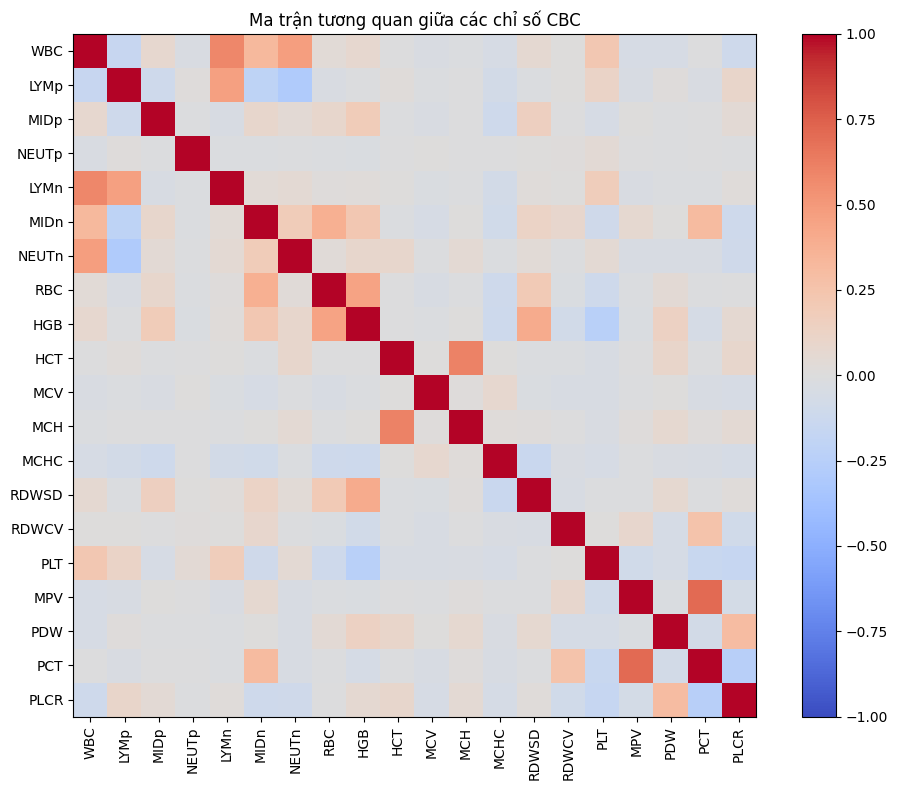

Các cặp tương quan cao (|r| > 0.85):
(không có nếu danh sách trống)


In [4]:
# Ma trận tương quan
num_cols = df.select_dtypes(include=np.number).columns.drop('ID', errors='ignore')
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=90)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
plt.colorbar(im)
plt.title('Ma trận tương quan giữa các chỉ số CBC')
plt.tight_layout()
plt.show()

print('Các cặp tương quan cao (|r| > 0.85):')
seen = set()
for i in corr.columns:
    for j in corr.columns:
        if i != j and abs(corr.loc[i, j]) > 0.85 and (j, i) not in seen:
            print(f'  {i} <-> {j}: r = {corr.loc[i, j]:.3f}')
            seen.add((i, j))
print('(không có nếu danh sách trống)')

## Nhận xét

- Không có missing value, không có dòng trùng lặp.
- **Phát hiện lỗi chất lượng nghiêm trọng**: nhiều giá trị vượt ngoài khoảng sinh học hợp lý (HGB âm, MCV âm, NEUTp/HCT/MPV vượt xa giới hạn trên) — gần như chắc chắn là lỗi nhập liệu/sai đơn vị, không phải outlier lâm sàng thật. **Bắt buộc lọc theo range hợp lý trước khi dùng.**
- Không có nhãn bệnh sẵn — cần tự sinh nhãn hoặc dùng cho unsupervised.
- Không phát hiện đa cộng tuyến nghiêm trọng giữa các chỉ số (|r| > 0.85).